In [1]:
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import numpy as np
import matplotlib.pyplot as plt
from bilby.core.prior import ConditionalPriorDict

## Uniform in sigma

In [2]:
priors = ConditionalPriorDict(filename="capture.prior")
N = 100_000
s = priors.sample(N)

q = np.asarray(s["mass_ratio"])
nu = q / (1.0 + q) ** 2
sig = np.asarray(s["sigma"])
dE = np.asarray(s["delta_energy"])  # E_0 - 1
pph = np.asarray(s["momentum"])  # p_phi^0

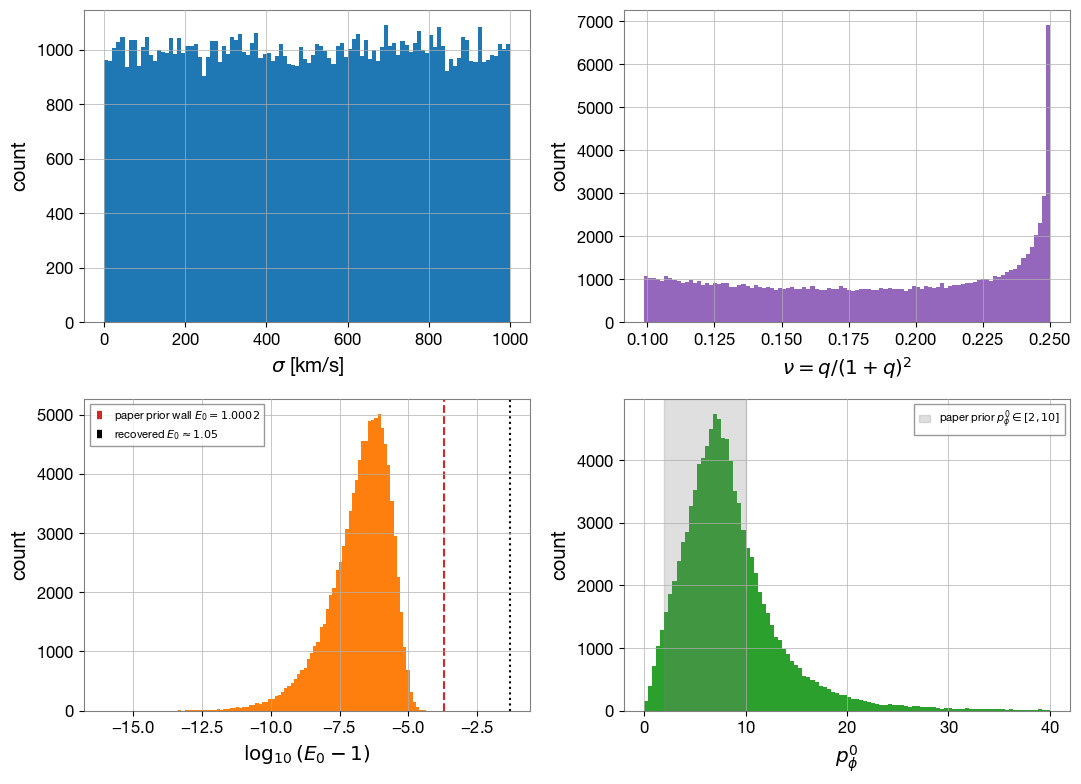

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

ax[0, 0].hist(sig, bins=100, color="C0")
ax[0, 0].set_xlabel(r"$\sigma$ [km/s]")
ax[0, 0].set_ylabel("count")

ax[0, 1].hist(nu, bins=100, color="C4")
ax[0, 1].set_xlabel(r"$\nu = q/(1+q)^2$")
ax[0, 1].set_ylabel("count")

ax[1, 0].hist(np.log10(dE), bins=100, color="C1")
ax[1, 0].axvline(
    np.log10(2e-4), color="C3", ls="--", label=r"paper prior wall $E_0=1.0002$"
)
ax[1, 0].axvline(np.log10(0.05), color="k", ls=":", label=r"recovered $E_0\approx1.05$")
ax[1, 0].set_xlabel(r"$\log_{10}(E_0 - 1)$")
ax[1, 0].set_ylabel("count")
ax[1, 0].legend(fontsize=8)

ax[1, 1].hist(pph, bins=100, range=(0, 40), color="C2")
ax[1, 1].axvspan(
    2, 10, color="grey", alpha=0.25, label=r"paper prior $p_\phi^0\in[2,10]$"
)
ax[1, 1].set_xlabel(r"$p_\phi^0$")
ax[1, 1].set_ylabel("count")
ax[1, 1].legend(fontsize=8)

fig.tight_layout()
plt.show()

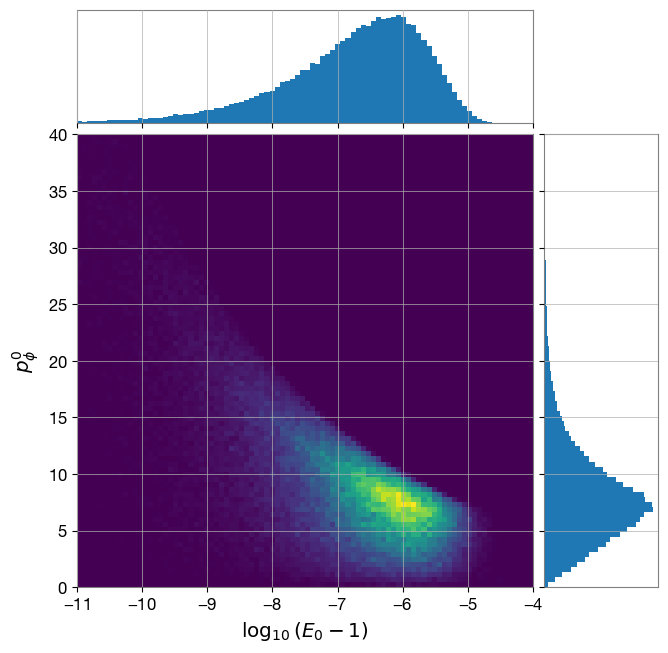

In [4]:
x = np.log10(dE)
y = pph
xr = (np.floor(np.percentile(x, 0.5)), np.ceil(np.percentile(x, 99.5)))
yr = (0.0, 40.0)

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.5, 7.5),
    gridspec_kw=dict(
        width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.04, hspace=0.04
    ),
)
ax_t, ax_j, ax_r = axes[0, 0], axes[1, 0], axes[1, 1]
axes[0, 1].axis("off")

ax_j.hist2d(x, y, bins=90, range=[xr, yr], cmap="viridis")
ax_j.set_xlabel(r"$\log_{10}(E_0 - 1)$")
ax_j.set_ylabel(r"$p_\phi^0$")

ax_t.hist(x, bins=90, range=xr, color="C0")
ax_t.set_xlim(xr)
ax_t.set_xticklabels([])
ax_t.set_yticks([])

ax_r.hist(y, bins=90, range=yr, orientation="horizontal", color="C0")
ax_r.set_ylim(yr)
ax_r.set_yticklabels([])
ax_r.set_xticks([])

plt.show()

## Log-uniform in sigma

In [5]:
priors = ConditionalPriorDict(filename="capture_loguniform.prior")
N = 100_000
s = priors.sample(N)

q = np.asarray(s["mass_ratio"])
nu = q / (1.0 + q) ** 2
sig = np.asarray(s["sigma"])
dE = np.asarray(s["delta_energy"])  # E_0 - 1
pph = np.asarray(s["momentum"])  # p_phi^0

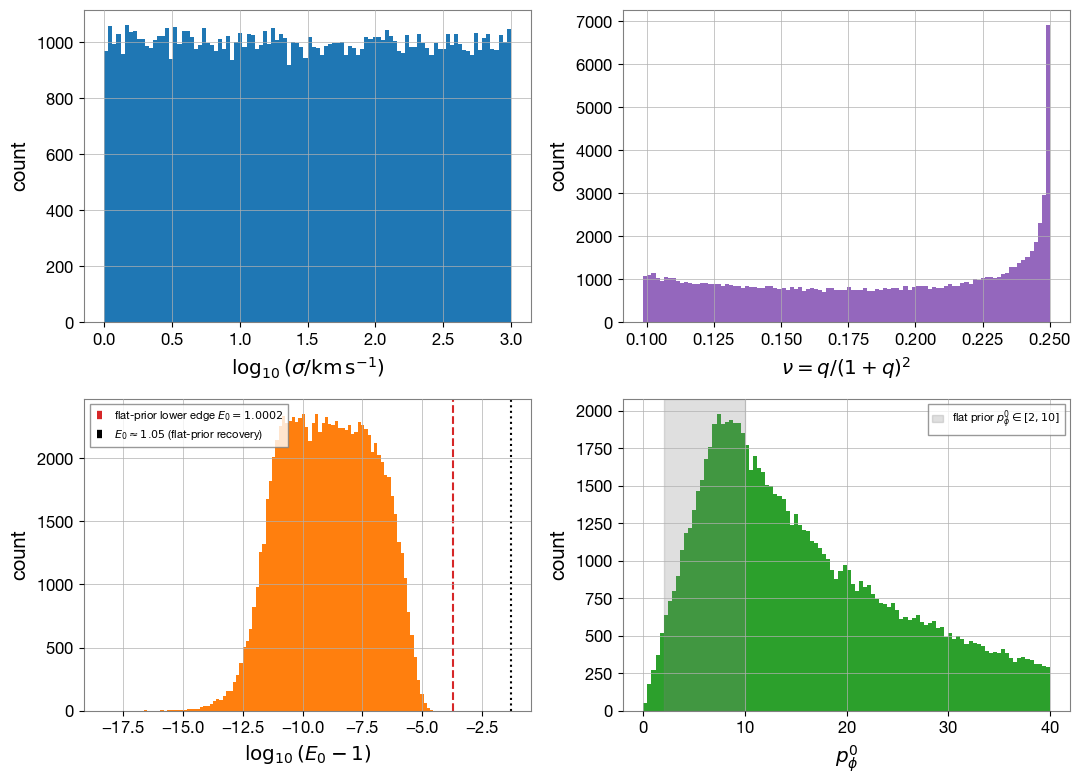

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

ax[0, 0].hist(np.log10(sig), bins=100, color="C0")
ax[0, 0].set_xlabel(r"$\log_{10}(\sigma / \mathrm{km\,s^{-1}})$")
ax[0, 0].set_ylabel("count")

ax[0, 1].hist(nu, bins=100, color="C4")
ax[0, 1].set_xlabel(r"$\nu = q/(1+q)^2$")
ax[0, 1].set_ylabel("count")

ax[1, 0].hist(np.log10(dE), bins=100, color="C1")
ax[1, 0].axvline(
    np.log10(2e-4), color="C3", ls="--", label=r"flat-prior lower edge $E_0=1.0002$"
)
ax[1, 0].axvline(
    np.log10(0.05), color="k", ls=":", label=r"$E_0\approx1.05$ (flat-prior recovery)"
)
ax[1, 0].set_xlabel(r"$\log_{10}(E_0 - 1)$")
ax[1, 0].set_ylabel("count")
ax[1, 0].legend(fontsize=8)

ax[1, 1].hist(pph, bins=100, range=(0, 40), color="C2")
ax[1, 1].axvspan(
    2, 10, color="grey", alpha=0.25, label=r"flat prior $p_\phi^0\in[2,10]$"
)
ax[1, 1].set_xlabel(r"$p_\phi^0$")
ax[1, 1].set_ylabel("count")
ax[1, 1].legend(fontsize=8)

fig.tight_layout()
plt.show()

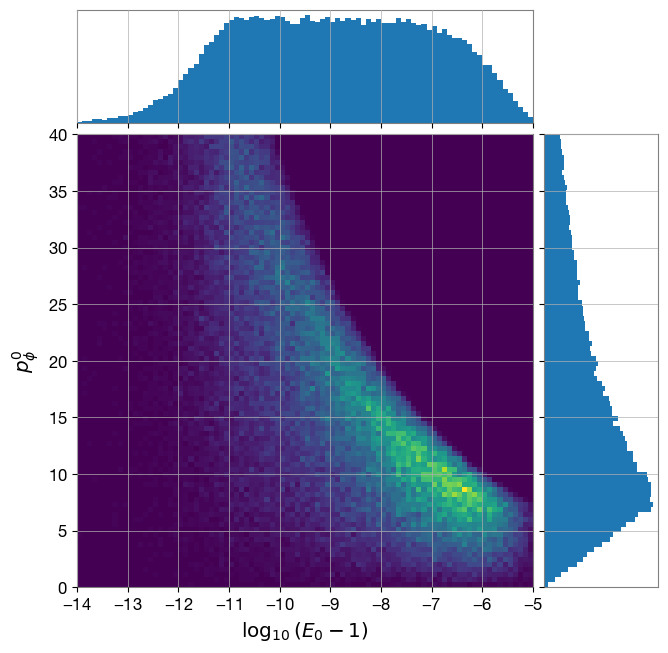

In [7]:
x = np.log10(dE)
y = pph
xr = (np.floor(np.percentile(x, 0.5)), np.ceil(np.percentile(x, 99.5)))
yr = (0.0, 40.0)

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.5, 7.5),
    gridspec_kw=dict(
        width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.04, hspace=0.04
    ),
)
ax_t, ax_j, ax_r = axes[0, 0], axes[1, 0], axes[1, 1]
axes[0, 1].axis("off")

ax_j.hist2d(x, y, bins=90, range=[xr, yr], cmap="viridis")
ax_j.set_xlabel(r"$\log_{10}(E_0 - 1)$")
ax_j.set_ylabel(r"$p_\phi^0$")

ax_t.hist(x, bins=90, range=xr, color="C0")
ax_t.set_xlim(xr)
ax_t.set_xticklabels([])
ax_t.set_yticks([])

ax_r.hist(y, bins=90, range=yr, orientation="horizontal", color="C0")
ax_r.set_ylim(yr)
ax_r.set_yticklabels([])
ax_r.set_xticks([])

plt.show()

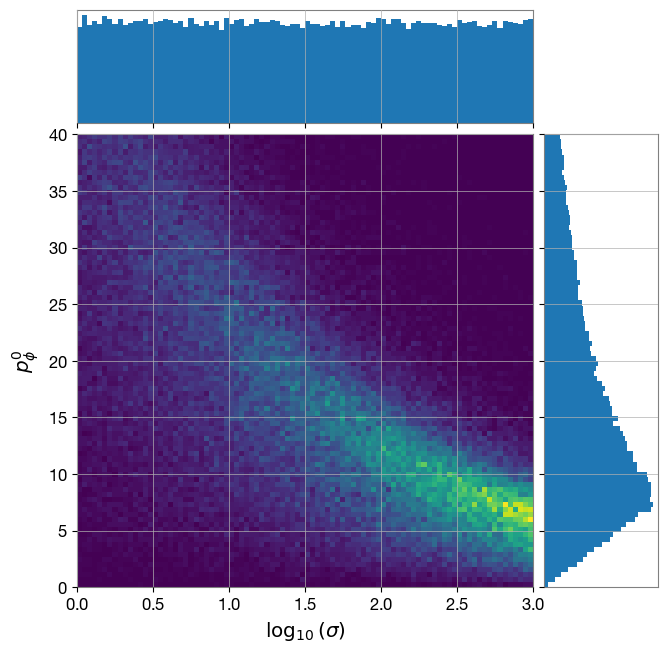

In [8]:
x = np.log10(sig)
y = pph
xr = (np.floor(np.percentile(x, 0.5)), np.ceil(np.percentile(x, 99.5)))
yr = (0.0, 40.0)

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.5, 7.5),
    gridspec_kw=dict(
        width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.04, hspace=0.04
    ),
)
ax_t, ax_j, ax_r = axes[0, 0], axes[1, 0], axes[1, 1]
axes[0, 1].axis("off")

ax_j.hist2d(x, y, bins=90, range=[xr, yr], cmap="viridis")
ax_j.set_xlabel(r"$\log_{10}(\sigma)$")
ax_j.set_ylabel(r"$p_\phi^0$")

ax_t.hist(x, bins=90, range=xr, color="C0")
ax_t.set_xlim(xr)
ax_t.set_xticklabels([])
ax_t.set_yticks([])

ax_r.hist(y, bins=90, range=yr, orientation="horizontal", color="C0")
ax_r.set_ylim(yr)
ax_r.set_yticklabels([])
ax_r.set_xticks([])

plt.show()

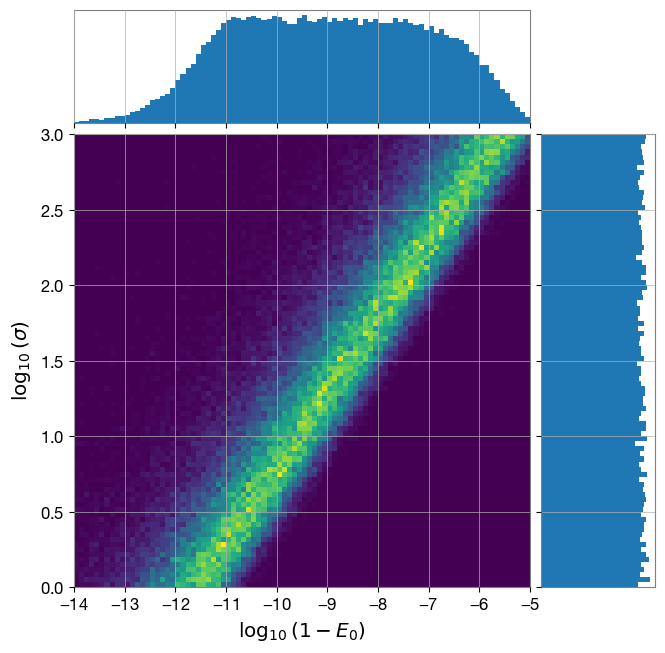

In [9]:
x = np.log10(dE)
y = np.log10(sig)
xr = (np.floor(np.percentile(x, 0.5)), np.ceil(np.percentile(x, 99.5)))
yr = (np.floor(np.percentile(y, 0.5)), np.ceil(np.percentile(y, 99.5)))

fig, axes = plt.subplots(
    2, 2,
    figsize=(7.5, 7.5),
    gridspec_kw=dict(
        width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.04, hspace=0.04
    ),
)
ax_t, ax_j, ax_r = axes[0, 0], axes[1, 0], axes[1, 1]
axes[0, 1].axis("off")

ax_j.hist2d(x, y, bins=90, range=[xr, yr], cmap="viridis")
ax_j.set_xlabel(r"$\log_{10}(1 - E_0)$")
ax_j.set_ylabel(r"$\log_{10}(\sigma)$")

ax_t.hist(x, bins=90, range=xr, color="C0")
ax_t.set_xlim(xr)
ax_t.set_xticklabels([])
ax_t.set_yticks([])

ax_r.hist(y, bins=90, range=yr, orientation="horizontal", color="C0")
ax_r.set_ylim(yr)
ax_r.set_yticklabels([])
ax_r.set_xticks([])

plt.show()

in-band fraction: 3.4%
p_phi^0 (in-band): median 2.48, 90% CI [1.35, 3.81]


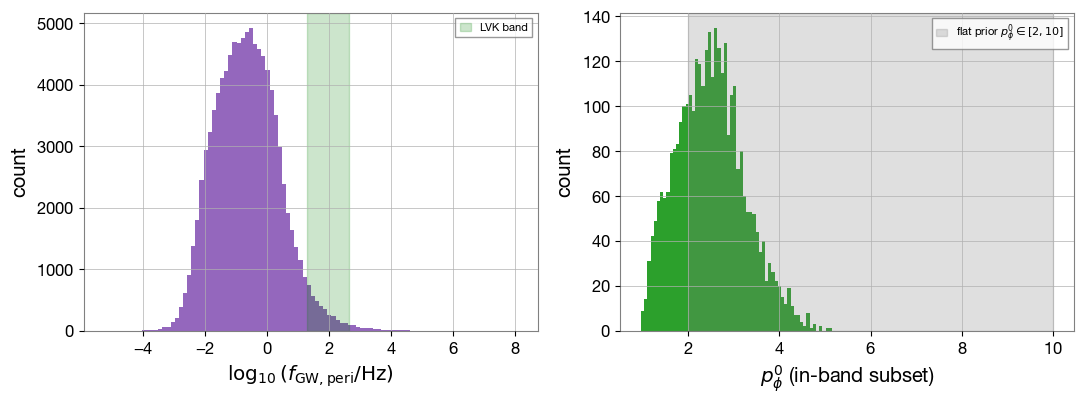

In [10]:
# In-band subsets
GMSUN_OVER_C3_S = lal.MTSUN_SI          # G M_sun / c^3 [s]
F_LOW, F_HIGH = 20.0, 448.0             # LVK analysis band (GW190521-like)

Mc = np.asarray(s["chirp_mass"])
Mtot = Mc * (1.0 + q) ** (6.0 / 5.0) / q ** (3.0 / 5.0)   # detector-frame total mass
rp_hat = pph ** 2 / 2.0
f_peri = (1.0 / np.pi) * np.sqrt(2.0 / rp_hat ** 3) / (GMSUN_OVER_C3_S * Mtot)
in_band = (f_peri >= F_LOW) & (f_peri <= F_HIGH)

lo, md_, hi = np.percentile(pph[in_band], [5, 50, 95])
print(f"in-band fraction: {in_band.mean():.1%}")
print(f"p_phi^0 (in-band): median {md_:.2f}, 90% CI [{lo:.2f}, {hi:.2f}]")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(np.log10(f_peri), bins=100, color="C4")
ax[0].axvspan(np.log10(F_LOW), np.log10(F_HIGH), color="green", alpha=0.2,
              label="LVK band")
ax[0].set_xlabel(r"$\log_{10}(f_{\rm GW,peri}/\mathrm{Hz})$")
ax[0].set_ylabel("count")
ax[0].legend(fontsize=8)

ax[1].hist(pph[in_band], bins=60, color="C2")
ax[1].axvspan(2, 10, color="grey", alpha=0.25, label=r"flat prior $p_\phi^0\in[2,10]$")
ax[1].set_xlabel(r"$p_\phi^0$ (in-band subset)")
ax[1].set_ylabel("count")
ax[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [11]:
import bilby
bilby.core.utils.random.seed(0)
_p = ConditionalPriorDict(filename="capture_loguniform.prior")
_s = _p.sample(400_000)
_q = np.asarray(_s["mass_ratio"])
_dE = np.asarray(_s["delta_energy"])
_pph = np.asarray(_s["momentum"])
_Mtot = np.asarray(_s["chirp_mass"]) * (1.0 + _q) ** (6.0 / 5.0) / _q ** (3.0 / 5.0)
_rp = _pph ** 2 / 2.0
_fpk = (1.0 / np.pi) * np.sqrt(2.0 / _rp ** 3) / (lal.MTSUN_SI * _Mtot)
_ib = (_fpk >= 11.0) & (_fpk <= 448.0)

pc = lambda a: np.percentile(a, [5, 50, 95])
e5, e50, e95 = pc(_dE)
p5, p50, p95 = pc(_pph)
b5, b50, b95 = pc(_pph[_ib])

print(f"E_0: {e5:.1e} -- {e50:.1e} -- {e95:.1e}")
print(f"p_phi^0: {p5:.1f} -- {p50:.1f} -- {p95:.1f}")

E_0: 1.4e-12 -- 1.2e-09 -- 1.1e-06
p_phi^0: 3.8 -- 15.0 -- 48.1
